# ___Mining and Heavy Equipment___

___Predicting Fuel Consumption for Heavy Duty Applications___

In [1]:
# Importing nessarcy Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    r2_score, # Coefficeient of determination (model fit)
    mean_squared_error, # penalizes large errors
    mean_absolute_error, # avearage absolue error
    explained_variance_score, # How much variance the model explains
    root_mean_squared_error # Root mean squared error regression loss.
)

## ___1 - Loading Data___

We will try to understand the data, clean, normalize and impute the data where ever possible to derive the best possible result out of the exsisting dataset.

Derived from - https://figshare.com/s/7e6f90fc08adc113f7a7?utm_source=copilot.com&file=54669416

In [2]:
# Reading Excel
df_main = pd.read_excel(r"D:\ML & AI\_Projects\Mining & Heavy Equipment\final_ori_data.xlsx", index_col = 0).iloc[1:].reset_index(drop=True)
df_main.head()

,date,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),road quality,shift work,Raise height difference,Width of working flat
0,2023-04-20 00:00:00,0.021914,RTH136,NaN,NaN,41.8,3.6,54.7,25.5,0,1,night shift,95,30
1,2023-04-21 00:00:00,0.028246,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0,1,day shift,95,30
2,2023-04-21 00:00:00,0.022779,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0,1,night shift,95,30
3,2023-04-22 00:00:00,0.027787,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0,1,day shift,95,30
4,2023-04-22 00:00:00,0.024141,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0,1,night shift,95,30


### ___Adding more data to make it scalable___
Instead of using only vehicle model name, using vehicle specifications as features.

In [3]:
vehical_specs = {
    "MT96L" : {
        "Engine power (HP)": 523,
        "Engine size (L)": 12.54,
        "Vehicle weight (kg)": 33000,
        "Transmission type": "Automatic",
        "Fuel Type": "Diesel",
        "Numbers of cylinder": 6,
        "Load Capacity": 65000
    },
    "RTH136":{
        "Engine power (HP)": 764,
        "Engine size (L)": 15.93,
        "Vehicle weight (kg)": 48000,
        "Transmission type": "Automatic",
        "Fuel Type": "Diesel",
        "Numbers of cylinder": 6,
        "Load Capacity": 100000
    },
    "SKT105E":{
        "Engine power (HP)": 523,
        "Engine size (L)": 12.54,
        "Vehicle weight (kg)": 38000,
        "Transmission type": "Automatic",
        "Fuel Type": "Diesel",
        "Numbers of cylinder": 6,
        "Load Capacity": 70000
    }
}

In [4]:
spec_df = pd.DataFrame.from_dict(vehical_specs, orient ='index')
spec_df

,Engine power (HP),Engine size (L),Vehicle weight (kg),Transmission type,Fuel Type,Numbers of cylinder,Load Capacity
MT96L,523,12.54,33000,Automatic,Diesel,6,65000
RTH136,764,15.93,48000,Automatic,Diesel,6,100000
SKT105E,523,12.54,38000,Automatic,Diesel,6,70000


In [5]:
df_main = df_main.merge(spec_df, left_on='vehicle model', right_index=True, how='left')

In [6]:
df_main

,date,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),...,shift work,Raise height difference,Width of working flat,Engine power (HP),Engine size (L),Vehicle weight (kg),Transmission type,Fuel Type,Numbers of cylinder,Load Capacity
0,2023-04-20 00:00:00,0.021914,RTH136,NaN,NaN,41.8,3.6,54.7,25.5,0,...,night shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
1,2023-04-21 00:00:00,0.028246,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0,...,day shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
2,2023-04-21 00:00:00,0.022779,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0,...,night shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
3,2023-04-22 00:00:00,0.027787,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0,...,day shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
4,2023-04-22 00:00:00,0.024141,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0,...,night shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,2023-05-21 00:00:00,0.067745,MT96L,NaN,NaN,64.6,5.8,78.4,54.1,0,...,night shift,110,30,523,12.54,33000,Automatic,Diesel,6,65000
288,2023-05-22 00:00:00,0.066437,MT96L,NaN,NaN,63,5.6,74.8,53.2,0.15,...,night shift,110,30,523,12.54,33000,Automatic,Diesel,6,65000
289,2023-05-22 00:00:00,0.066437,MT96L,NaN,NaN,63,5.6,74.8,53.2,0.15,...,night shift,110,30,523,12.54,33000,Automatic,Diesel,6,65000
290,2023-05-23 00:00:00,0.04724,MT96L,NaN,NaN,63.1,6.9,74.8,52.2,0.02,...,day shift,110,30,523,12.54,33000,Automatic,Diesel,6,65000


In [7]:
print(df_main.dtypes)

date                                          object
Ton-kilometer fuel consumption L / km / t     object
vehicle model                                 object
Mileage km                                    object
Actual fueling quantity L                     object
Average temperature ( ° F )                   object
Average wind speed ( knots )                  object
Maximum temperature ( ° F )                   object
Minimum temperature ( ° F )                   object
Precipitation ( in )                          object
road quality                                  object
shift work                                    object
Raise height difference                       object
Width of working flat                         object
Engine power (HP)                              int64
Engine size (L)                              float64
Vehicle weight (kg)                            int64
Transmission type                             object
Fuel Type                                     

In [8]:
df_main.drop(columns = ['vehicle model'], inplace = True)

In [9]:
num_cols = df_main.columns

for col in num_cols:
    df_main[col] = pd.to_numeric(df_main[col], errors='ignore')

# then convert numeric columns to float64
num_cols = df_main.select_dtypes(include='number').columns
df_main[num_cols] = df_main[num_cols].astype('float64')

C:\Users\ANISH RANE\AppData\Local\Temp\ipykernel_20764\2807878066.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_main[col] = pd.to_numeric(df_main[col], errors='ignore')


In [10]:
# verify
print(df_main.dtypes)

date                                         datetime64[ns]
Ton-kilometer fuel consumption L / km / t           float64
Mileage km                                          float64
Actual fueling quantity L                            object
Average temperature ( ° F )                         float64
Average wind speed ( knots )                        float64
Maximum temperature ( ° F )                         float64
Minimum temperature ( ° F )                         float64
Precipitation ( in )                                float64
road quality                                        float64
shift work                                           object
Raise height difference                             float64
Width of working flat                               float64
Engine power (HP)                                   float64
Engine size (L)                                     float64
Vehicle weight (kg)                                 float64
Transmission type                       

In [11]:
df_main['Actual fueling quantity L'] = pd.to_numeric(
    df_main['Actual fueling quantity L']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex = True),
    errors = 'coerce'
)
# verify
print(df_main.dtypes)

date                                         datetime64[ns]
Ton-kilometer fuel consumption L / km / t           float64
Mileage km                                          float64
Actual fueling quantity L                           float64
Average temperature ( ° F )                         float64
Average wind speed ( knots )                        float64
Maximum temperature ( ° F )                         float64
Minimum temperature ( ° F )                         float64
Precipitation ( in )                                float64
road quality                                        float64
shift work                                           object
Raise height difference                             float64
Width of working flat                               float64
Engine power (HP)                                   float64
Engine size (L)                                     float64
Vehicle weight (kg)                                 float64
Transmission type                       

## ___2 - Basic EDA (Understanding the data)___

* Lets understand the data with the help of ___shape, size, info and describe___
* Understand the ___null count___ present in the data

In [12]:
df_main.size

5840

In [13]:
df_main.shape

(292, 20)

In [14]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   date                                       292 non-null    datetime64[ns]
 1   Ton-kilometer fuel consumption L / km / t  292 non-null    float64       
 2   Mileage km                                 132 non-null    float64       
 3   Actual fueling quantity L                  150 non-null    float64       
 4   Average temperature ( ° F )                292 non-null    float64       
 5   Average wind speed ( knots )               292 non-null    float64       
 6   Maximum temperature ( ° F )                292 non-null    float64       
 7   Minimum temperature ( ° F )                292 non-null    float64       
 8   Precipitation ( in )                       292 non-null    float64       
 9   road quality         

In [15]:
df_main.describe()

,date,Ton-kilometer fuel consumption L / km / t,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),road quality,Raise height difference,Width of working flat,Engine power (HP),Engine size (L),Vehicle weight (kg),Numbers of cylinder,Load Capacity
count,292,292.000000,132.000000,150.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.0,292.000000,292.000000,292.000000,292.0,292.000000
mean,2023-05-19 21:46:50.958904064,0.047772,13905.182576,337.246667,62.834247,5.538014,75.421918,48.873288,0.013288,1.171233,108.818493,30.0,632.770548,14.084075,40191.780822,6.0,81301.369863
min,2023-04-20 00:00:00,0.020182,4114.000000,37.000000,41.800000,2.600000,51.100000,25.500000,0.000000,1.000000,95.000000,30.0,523.000000,12.540000,33000.000000,6.0,65000.000000
25%,2023-05-18 00:00:00,0.026466,10253.500000,252.250000,62.600000,4.200000,74.800000,47.700000,0.000000,1.000000,110.000000,30.0,523.000000,12.540000,33000.000000,6.0,65000.000000
50%,2023-05-23 00:00:00,0.051510,11587.000000,343.000000,64.600000,5.800000,78.000000,50.550000,0.000000,1.000000,110.000000,30.0,523.000000,12.540000,38000.000000,6.0,70000.000000
75%,2023-05-26 00:00:00,0.065584,17859.750000,429.750000,67.400000,6.100000,78.400000,52.200000,0.000000,1.000000,110.000000,30.0,764.000000,15.930000,48000.000000,6.0,100000.000000
max,2023-05-31 00:00:00,0.128571,24160.000000,602.000000,75.100000,7.200000,87.100000,59.700000,0.150000,3.000000,110.000000,30.0,764.000000,15.930000,48000.000000,6.0,100000.000000
std,NaN,0.020061,4907.117503,117.553354,6.266427,1.186070,6.326690,6.059321,0.036366,0.560554,4.047561,0.0,120.227414,1.691166,7262.212199,0.0,17176.612351


In [16]:
def null_count(df):
    null_df = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': np.round(((df.isnull().sum()/len(df))*100),2)
    })

    null_df = null_df[null_df['Null Count']>0].sort_values(by = "Null %", ascending = False)
    
    return null_df

In [17]:
null_count(df_main)

,Null Count,Null %
Mileage km,160,54.79
Actual fueling quantity L,142,48.63


## ___3 - Deep EDA (Before Scaling)___

* ___Plotting Graphs___ and having a ___in-depth information___ about the data

In [18]:
# Distribute the Set of Columns
date_cols = df_main.select_dtypes(include='datetime64[ns]').columns
cat_cols = df_main.select_dtypes(include='string').columns
num_cols = df_main.select_dtypes(include='number').columns

#### ___A) Understanding Numerical Columns___

In [19]:
stats = df_main[num_cols].describe().T
stats['skew'] = df_main[num_cols].skew()
stats['kurtosis'] = df_main[num_cols].kurt()
stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Ton-kilometer fuel consumption L / km / t,292.0,0.047772,0.020061,0.020182,0.026466,0.05151,0.065584,0.128571,0.140741,-0.740259
Mileage km,132.0,13905.182576,4907.117503,4114.000000,10253.500000,11587.00000,17859.750000,24160.000000,0.138257,-1.008420
Actual fueling quantity L,150.0,337.246667,117.553354,37.000000,252.250000,343.00000,429.750000,602.000000,-0.154956,-0.723705
Average temperature ( ° F ),292.0,62.834247,6.266427,41.800000,62.600000,64.60000,67.400000,75.100000,-1.471275,1.835325
Average wind speed ( knots ),292.0,5.538014,1.186070,2.600000,4.200000,5.80000,6.100000,7.200000,-0.329928,-0.912601
Maximum temperature ( ° F ),292.0,75.421918,6.326690,51.100000,74.800000,78.00000,78.400000,87.100000,-1.958128,4.209758
Minimum temperature ( ° F ),292.0,48.873288,6.059321,25.500000,47.700000,50.55000,52.200000,59.700000,-1.479374,2.090503
Precipitation ( in ),292.0,0.013288,0.036366,0.000000,0.000000,0.00000,0.000000,0.150000,3.074231,8.462378
road quality,292.0,1.171233,0.560554,1.000000,1.000000,1.00000,1.000000,3.000000,2.977348,6.911899
Raise height difference,292.0,108.818493,4.047561,95.000000,110.000000,110.00000,110.000000,110.000000,-3.143656,7.936887


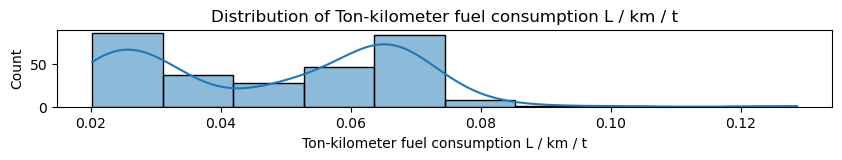

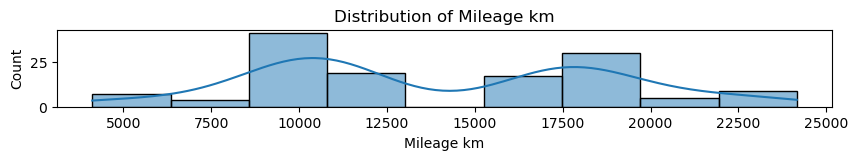

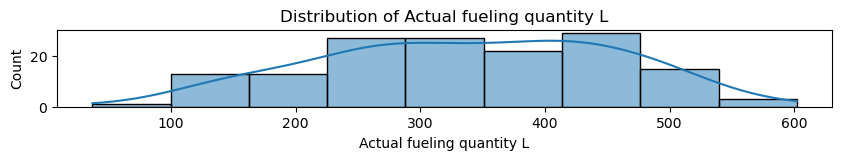

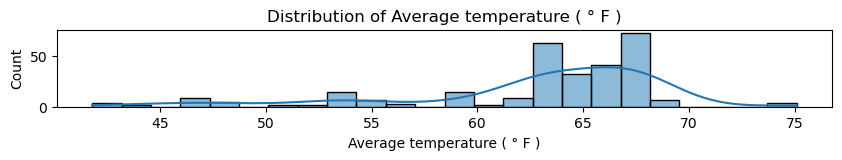

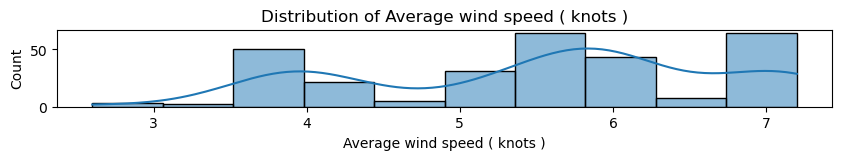

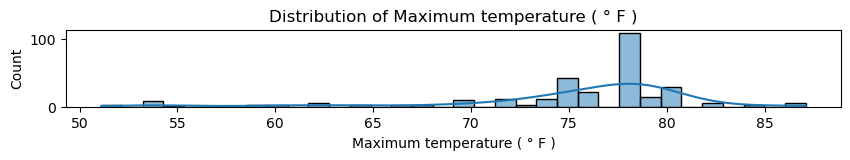

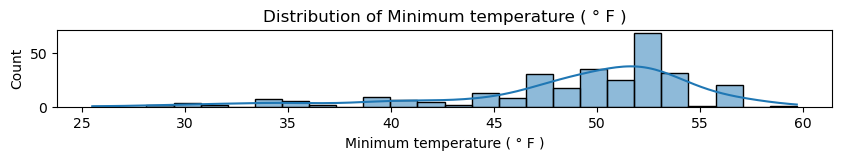

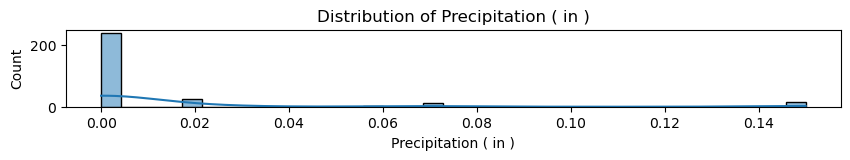

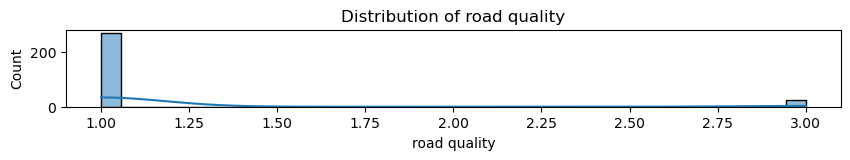

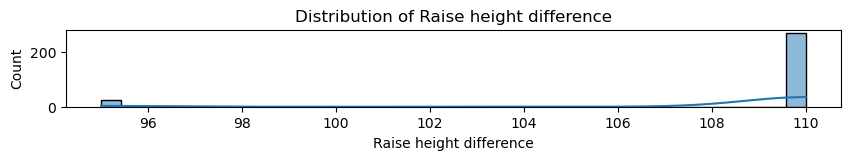

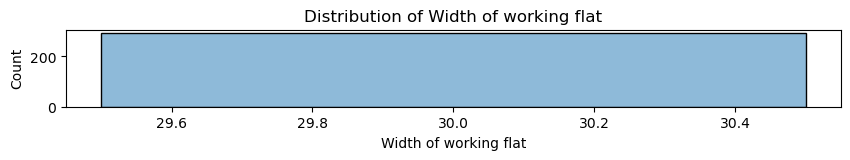

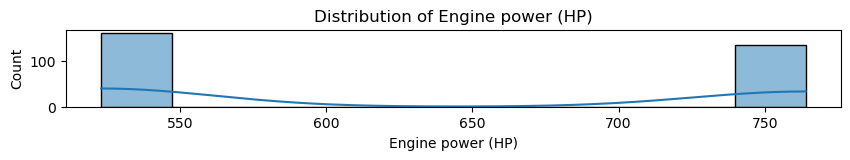

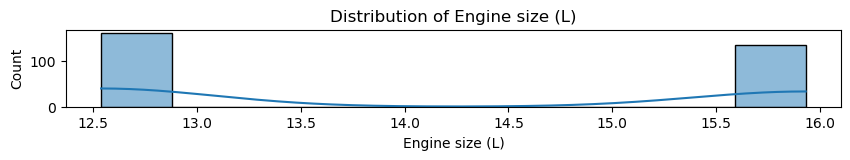

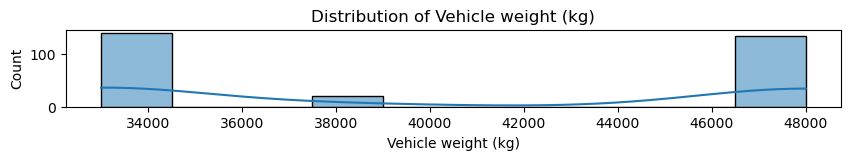

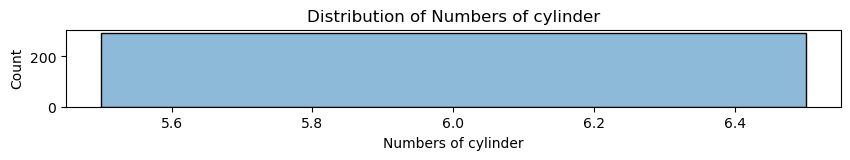

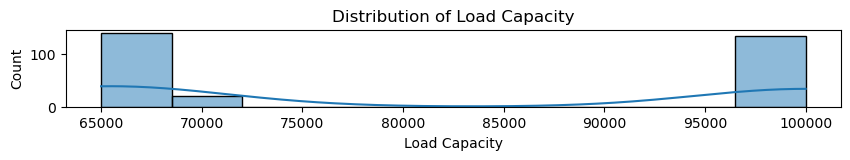

In [20]:
# Plotting Hist Plot for understanding data distribution
for col in num_cols:
    plt.figure(figsize=(10,1))
    sns.histplot(df_main[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

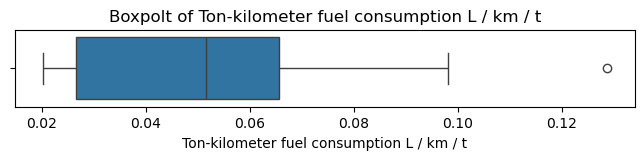

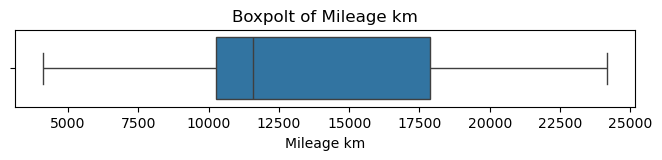

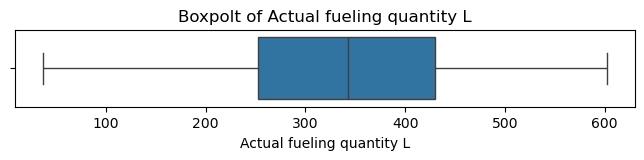

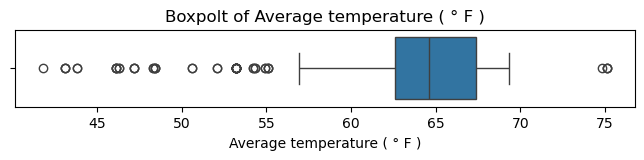

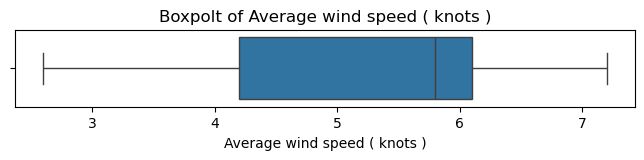

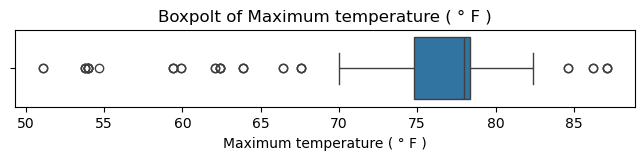

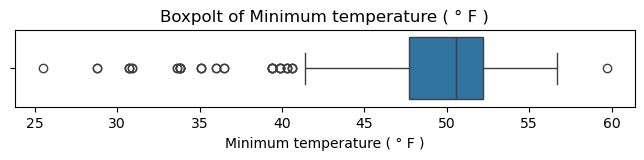

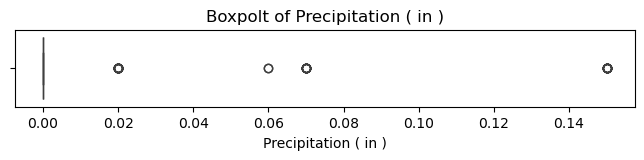

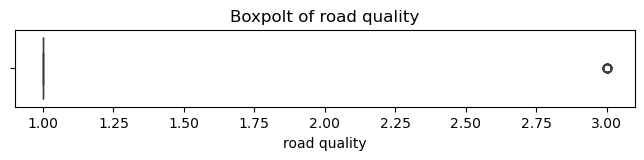

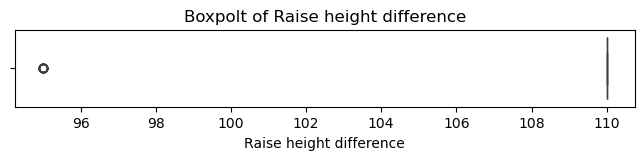

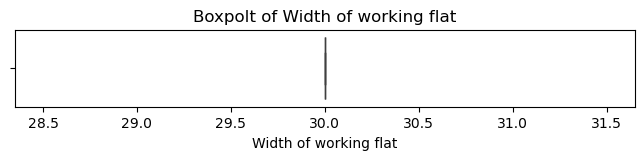

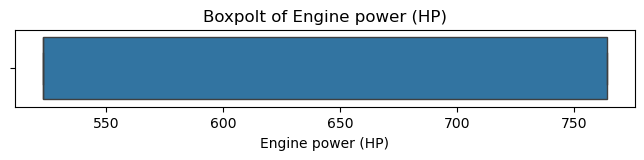

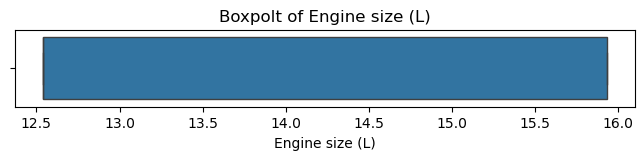

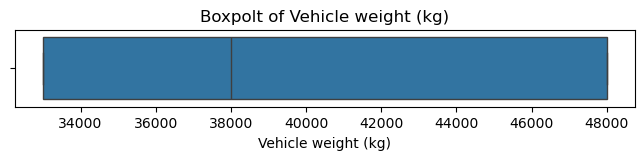

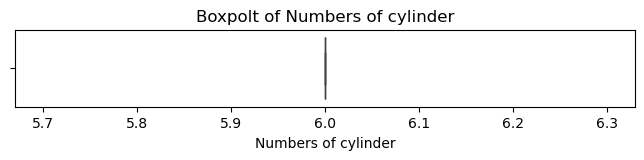

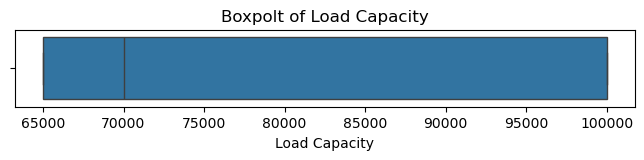

In [21]:
# Plotting Box plot to understand the distribution and the outliers
for col in num_cols:
    plt.figure(figsize=(8,1))
    sns.boxplot(x = df_main[col])
    plt.title(f"Boxpolt of {col}")
    plt.show()

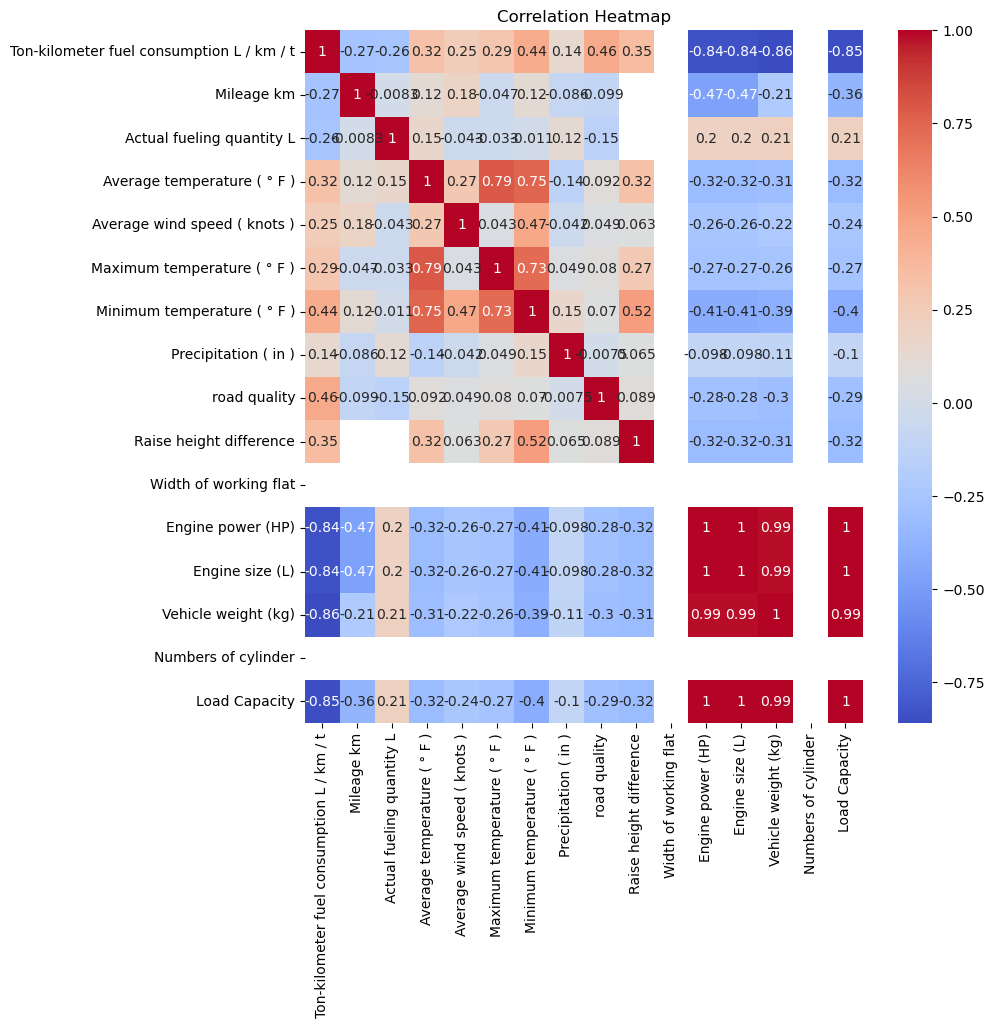

In [22]:
# Plotting the Correlation graph the understang Colinear relation
corr = df_main[num_cols].corr()

plt.figure(figsize = (9,9))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### ___B) Understanding Categorical Columns___

In [23]:
for col in cat_cols:
    print(df_main[col].value_counts())

In [24]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=df_main[col])
    plt.title(f"Countplot of {col}")
    plt.show()

 ___Target vs Category___

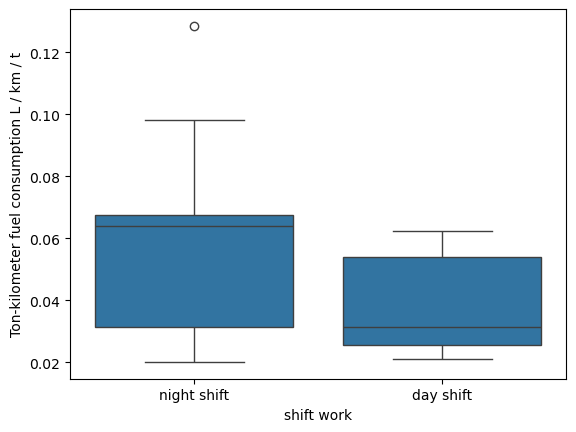

In [25]:
sns.boxplot(x='shift work',y='Ton-kilometer fuel consumption L / km / t', data=df_main)
plt.show()

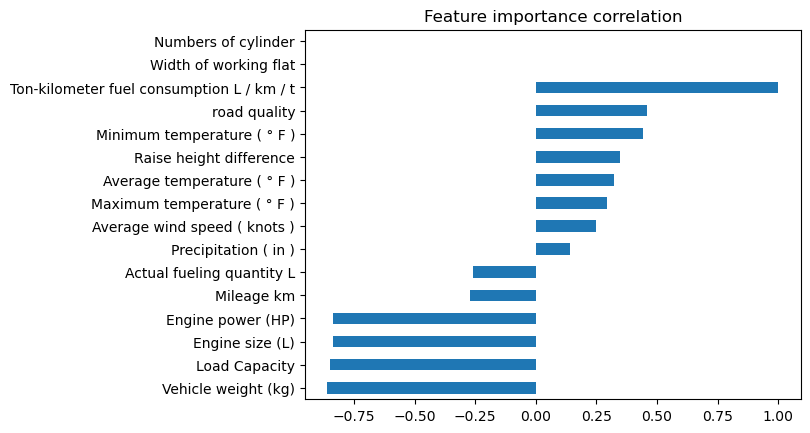

In [26]:
target = 'Ton-kilometer fuel consumption L / km / t'

corr_target = df_main[num_cols].corr()[target].sort_values()

corr_target.plot(kind='barh')
plt.title("Feature importance correlation")
plt.show()


## ___4 - Feature Engineering___

* Deriving new time features from exsisting date
* Dropping columns
* One - Hot encoding categorical variables

In [27]:
df_main.columns

Index(['date', 'Ton-kilometer fuel consumption L / km / t', 'Mileage km',
       'Actual fueling quantity L', 'Average temperature ( ° F )',
       'Average wind speed ( knots )', 'Maximum temperature ( ° F )',
       'Minimum temperature ( ° F )', 'Precipitation ( in )', 'road quality',
       'shift work', 'Raise height difference', 'Width of working flat',
       'Engine power (HP)', 'Engine size (L)', 'Vehicle weight (kg)',
       'Transmission type', 'Fuel Type', 'Numbers of cylinder',
       'Load Capacity'],
      dtype='object')

In [28]:
# Extracting Usefull data from date 
df_main['dayofweek'] = df_main['date'].dt.dayofweek
df_main['dayofyear'] = df_main['date'].dt.dayofyear

In [29]:
# Cyclic Encoding
df_main['dayofyear_sin'] = np.sin(2*np.pi*df_main['dayofyear']/365)
df_main['dayofyear_cos'] = np.cos(2*np.pi*df_main['dayofyear']/365)

df_main.drop(columns = ['dayofyear'], inplace = True)

In [30]:
df_main.columns

Index(['date', 'Ton-kilometer fuel consumption L / km / t', 'Mileage km',
       'Actual fueling quantity L', 'Average temperature ( ° F )',
       'Average wind speed ( knots )', 'Maximum temperature ( ° F )',
       'Minimum temperature ( ° F )', 'Precipitation ( in )', 'road quality',
       'shift work', 'Raise height difference', 'Width of working flat',
       'Engine power (HP)', 'Engine size (L)', 'Vehicle weight (kg)',
       'Transmission type', 'Fuel Type', 'Numbers of cylinder',
       'Load Capacity', 'dayofweek', 'dayofyear_sin', 'dayofyear_cos'],
      dtype='object')

In [31]:
# Dropping Date and As we have average temperature we dont need Min and Max Temp
df_main.drop(columns =['date', 'Maximum temperature ( ° F )', 'Minimum temperature ( ° F )'], inplace = True)

In [32]:
# Only 1 unique value → no variance → dropping them.
df_main.drop(columns = ['Width of working flat', 'Numbers of cylinder'], inplace = True)

In [33]:
df_main.columns

Index(['Ton-kilometer fuel consumption L / km / t', 'Mileage km',
       'Actual fueling quantity L', 'Average temperature ( ° F )',
       'Average wind speed ( knots )', 'Precipitation ( in )', 'road quality',
       'shift work', 'Raise height difference', 'Engine power (HP)',
       'Engine size (L)', 'Vehicle weight (kg)', 'Transmission type',
       'Fuel Type', 'Load Capacity', 'dayofweek', 'dayofyear_sin',
       'dayofyear_cos'],
      dtype='object')

### ___A) One Hot Encoding for Categorical Varialbles___

In [34]:
df_main.select_dtypes(include = 'object').columns

Index(['shift work', 'Transmission type', 'Fuel Type'], dtype='object')

In [35]:
# Categorical Columns 
cat_cols = df_main.select_dtypes(include = 'object').columns

# Encoding
df_main = pd.get_dummies(df_main, columns = cat_cols, drop_first = True)

In [36]:
df_main.columns

Index(['Ton-kilometer fuel consumption L / km / t', 'Mileage km',
       'Actual fueling quantity L', 'Average temperature ( ° F )',
       'Average wind speed ( knots )', 'Precipitation ( in )', 'road quality',
       'Raise height difference', 'Engine power (HP)', 'Engine size (L)',
       'Vehicle weight (kg)', 'Load Capacity', 'dayofweek', 'dayofyear_sin',
       'dayofyear_cos', 'shift work_night shift'],
      dtype='object')

In [37]:
df_main = pd.get_dummies(df_main, columns = ['dayofweek'], drop_first = True)

In [38]:
bool_cols = df_main.select_dtypes(include = 'bool').columns

df_main[bool_cols] = df_main[bool_cols].astype(int)

In [39]:
df_main.head()

,Ton-kilometer fuel consumption L / km / t,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Precipitation ( in ),road quality,Raise height difference,Engine power (HP),Engine size (L),...,Load Capacity,dayofyear_sin,dayofyear_cos,shift work_night shift,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6
0,0.021914,NaN,NaN,41.8,3.6,0.0,1.0,95.0,764.0,15.93,...,100000.0,0.948362,-0.317191,1,0,0,1,0,0,0
1,0.028246,NaN,NaN,48.3,3.3,0.0,1.0,95.0,764.0,15.93,...,100000.0,0.942761,-0.333469,0,0,0,0,1,0,0
2,0.022779,NaN,NaN,48.3,3.3,0.0,1.0,95.0,764.0,15.93,...,100000.0,0.942761,-0.333469,1,0,0,0,1,0,0
3,0.027787,NaN,NaN,52.1,5.8,0.0,1.0,95.0,764.0,15.93,...,100000.0,0.936881,-0.349647,0,0,0,0,0,1,0
4,0.024141,NaN,NaN,52.1,5.8,0.0,1.0,95.0,764.0,15.93,...,100000.0,0.936881,-0.349647,1,0,0,0,0,1,0


In [40]:
df_main.nunique()

Ton-kilometer fuel consumption L / km / t    257
Mileage km                                   131
Actual fueling quantity L                    122
Average temperature ( ° F )                   37
Average wind speed ( knots )                  18
Precipitation ( in )                           5
road quality                                   2
Raise height difference                        2
Engine power (HP)                              2
Engine size (L)                                2
Vehicle weight (kg)                            3
Load Capacity                                  3
dayofyear_sin                                 41
dayofyear_cos                                 41
shift work_night shift                         2
dayofweek_1                                    2
dayofweek_2                                    2
dayofweek_3                                    2
dayofweek_4                                    2
dayofweek_5                                    2
dayofweek_6         

## ___4 -Splitting Data set in X and Y for Train and Test___

In [41]:
y = df_main['Ton-kilometer fuel consumption L / km / t']
X = df_main.drop(columns = 'Ton-kilometer fuel consumption L / km / t')

In [42]:
# Splitting the data Set to avoid data leakage including Train, Validation and test

# Slipt into Train and Temp
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
print("X_train Size:",X_train.shape)
print("X_test Size:",X_test.shape)

X_train Size: (233, 20)
X_test Size: (59, 20)


Now we have,
* X_train, y_train = 80%
* X_val, y_val = 10%
* X_test, y_test = 10%

## ___5 - Imputing missing values___

### ___Using Iterative Imputer for Numerical Columns___

In [43]:
print(null_count(df_main))
print(null_count(X_train))
print(null_count(X_test))

                           Null Count  Null %
Mileage km                        160   54.79
Actual fueling quantity L         142   48.63
                           Null Count  Null %
Mileage km                        127   54.51
Actual fueling quantity L         112   48.07
                           Null Count  Null %
Mileage km                         33   55.93
Actual fueling quantity L          30   50.85


In [44]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

X_train_imp = X_train.copy() # Creating Copy of Train dataframe
X_test_imp = X_test.copy() # Creating Copy of Test dataframe

# Store dataframes in a dictionary
datasets = {
    "train": X_train_imp,
    "test": X_test_imp
}

num_cols = X_train_imp.select_dtypes(include=['number']).columns.tolist()

imputer = IterativeImputer(random_state = 42)

imputer.fit(X_train_imp[num_cols])

for name, data in datasets.items():
    datasets[name][num_cols] = imputer.transform(data[num_cols])

In [45]:
print(null_count(df_main))
print(null_count(X_train_imp))
print(null_count(X_test_imp))

                           Null Count  Null %
Mileage km                        160   54.79
Actual fueling quantity L         142   48.63
Empty DataFrame
Columns: [Null Count, Null %]
Index: []
Empty DataFrame
Columns: [Null Count, Null %]
Index: []


## ___6 - Scaling Data by using RobustScaler___

In [46]:
X_train_imp.columns

Index(['Mileage km', 'Actual fueling quantity L',
       'Average temperature ( ° F )', 'Average wind speed ( knots )',
       'Precipitation ( in )', 'road quality', 'Raise height difference',
       'Engine power (HP)', 'Engine size (L)', 'Vehicle weight (kg)',
       'Load Capacity', 'dayofyear_sin', 'dayofyear_cos',
       'shift work_night shift', 'dayofweek_1', 'dayofweek_2', 'dayofweek_3',
       'dayofweek_4', 'dayofweek_5', 'dayofweek_6'],
      dtype='object')

In [47]:
X_train_imp.nunique()

Mileage km                      193
Actual fueling quantity L       173
Average temperature ( ° F )      36
Average wind speed ( knots )     18
Precipitation ( in )              5
road quality                      2
Raise height difference           2
Engine power (HP)                 2
Engine size (L)                   2
Vehicle weight (kg)               3
Load Capacity                     3
dayofyear_sin                    40
dayofyear_cos                    40
shift work_night shift            2
dayofweek_1                       2
dayofweek_2                       2
dayofweek_3                       2
dayofweek_4                       2
dayofweek_5                       2
dayofweek_6                       2
dtype: int64

In [48]:
from sklearn.preprocessing import RobustScaler

scale_cols = [
    'Mileage km',
    'Actual fueling quantity L',
    'Average temperature ( ° F )',
    'Average wind speed ( knots )',
    'Vehicle weight (kg)',
    'Load Capacity',
]

scaler = RobustScaler()

scaler.fit(X_train_imp[scale_cols])

X_train_imp[scale_cols] = scaler.transform(X_train_imp[scale_cols])
X_test_imp[scale_cols] = scaler.transform(X_test_imp[scale_cols])

In [49]:
X_train_imp[scale_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Mileage km,233.0,0.064324,0.662366,-0.677335,-0.565871,0.0,0.434129,1.652735
Actual fueling quantity L,233.0,-0.467833,0.727038,-2.829567,-0.917364,0.0,0.082636,0.949878
Average temperature ( ° F ),233.0,-0.383374,1.376622,-4.956522,-0.391304,0.0,0.608696,2.282609
Average wind speed ( knots ),233.0,-0.101459,0.491387,-1.280000,-0.640000,0.0,0.360000,0.560000
Vehicle weight (kg),233.0,0.125894,0.481837,-0.333333,-0.333333,0.0,0.666667,0.666667
Load Capacity,233.0,0.301655,0.488349,-0.142857,-0.142857,0.0,0.857143,0.857143


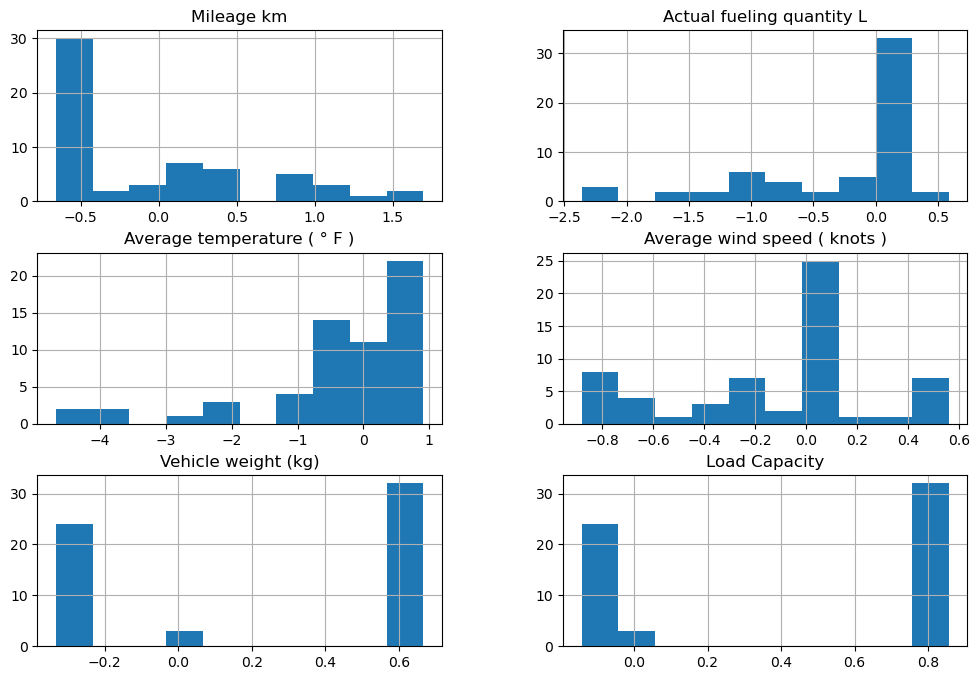

In [50]:
X_test_imp[scale_cols].hist(figsize=(12,8))
plt.show()

## ___7 - Evaluation Fuction___

In [51]:
def evaluate_model_df(model, X_train, y_train, X_test, y_test, model_name = 'Model'):

    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics Dictionary
    metrics = {
        "Model": model_name,

        "Train_MSE": mean_squared_error(y_train, y_train_pred),
        "Test_MSE": mean_squared_error(y_test, y_test_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Train_MAE": mean_absolute_error(y_train, y_train_pred),
        "Test_MAE": mean_absolute_error(y_test, y_test_pred),
        "Train_R2": r2_score(y_train, y_train_pred),
        "Test_R2": r2_score(y_test, y_test_pred),
        "Train_Explained_Var": explained_variance_score(y_train, y_train_pred),
        "Test_Explained_Var": explained_variance_score(y_test, y_test_pred)
    }

    return pd.DataFrame([metrics])

In [52]:
def plot_residual(model, X_test, y_test):
    y_test_pred = model.predict(X_test)
    residuals = y_test - y_test_pred
    
    plt.scatter(y_test_pred, residuals)
    plt.axhline(0, linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    
    return plt.show()

## ___7 - Traning Model Ridge Regression___

### ___A) - Model Ridge Regression___

In [53]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas = alphas, cv = 10)
ridge_cv.fit(X_train_imp, y_train)

print("Best alpha:", ridge_cv.alpha_)

Best alpha: 0.004641588833612782


In [54]:
ridge = Ridge(alpha=ridge_cv.alpha_, random_state = 42)

In [55]:
ridge_scores = cross_val_score(ridge, X_train_imp, y_train, cv = 10, scoring = 'r2')

print("Ridge_CV R2 mean:", ridge_scores.mean())
print("Ridge_CV R2 std:", ridge_scores.std())

Ridge_CV R2 mean: 0.8349433528879203
Ridge_CV R2 std: 0.05845796121661565


In [56]:
ridge.fit(X_train_imp, y_train)

,alpha,np.float64(0....1588833612782)
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [57]:
ridge_results = evaluate_model_df(
    ridge,
    X_train_imp, y_train,
    X_test_imp, y_test,
    model_name = "Ridge"
)
ridge_results

,Model,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Train_Explained_Var,Test_Explained_Var
0,Ridge,0.000059,0.000076,0.007688,0.008699,0.005377,0.006889,0.858641,0.770314,0.858641,0.782378


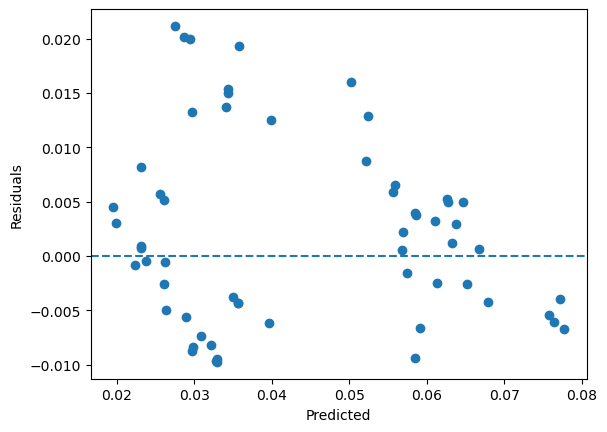

In [58]:
plot_residual(ridge, X_test_imp, y_test)

In [59]:
coefficients = pd.Series(ridge.coef_, index=X_train.columns)
coefficients.sort_values(ascending=False)

dayofyear_sin                   5.822329e-02
Precipitation ( in )            3.961729e-02
shift work_night shift          6.662505e-03
road quality                    6.543587e-03
dayofweek_4                     4.690717e-03
dayofweek_5                     2.936629e-03
dayofweek_1                     2.369981e-03
dayofweek_2                     2.367283e-03
Average wind speed ( knots )    1.643860e-03
dayofweek_6                     1.581828e-03
Engine power (HP)               6.885172e-05
Engine size (L)                 9.684874e-07
dayofweek_3                    -2.913703e-04
Raise height difference        -6.895541e-04
Average temperature ( ° F )    -7.493383e-04
Mileage km                     -1.293480e-03
Actual fueling quantity L      -2.134017e-03
Load Capacity                  -1.339418e-02
Vehicle weight (kg)            -3.125346e-02
dayofyear_cos                  -9.561290e-02
dtype: float64

### ___B) - Model Random Forst Regression___

In [60]:
rf = RandomForestRegressor(
    n_estimators = 300,
    max_depth = 8,
    min_samples_split = 5,
    random_state = 42
)

rf_scores = cross_val_score(rf, X_train_imp, y_train, cv = 5, scoring = 'r2')

print("RF CV R2 mean:", rf_scores.mean())
print("RF CV R2 std:", rf_scores.std())

RF CV R2 mean: 0.8839146644612299
RF CV R2 std: 0.05368768371974417


In [61]:
rf.fit(X_train_imp, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,8
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
rf_results = evaluate_model_df(
    rf,
    X_train_imp, y_train,
    X_test_imp, y_test,
    model_name = "RF"
)
rf_results

,Model,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Train_Explained_Var,Test_Explained_Var
0,RF,0.000016,0.000034,0.003971,0.00583,0.002319,0.004548,0.962295,0.896838,0.962297,0.903058


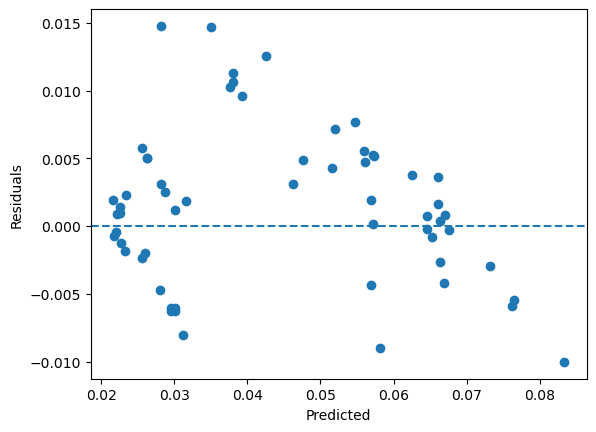

In [63]:
plot_residual(rf, X_test_imp, y_test)

### ___C) - Model XGBoost Regression___

In [64]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')

print("XGB CV R2 mean:", xgb_scores.mean())
print("XGB CV R2 std:", xgb_scores.std())

XGB CV R2 mean: 0.8861070839612626
XGB CV R2 std: 0.053293434222082395


In [65]:
xgb.fit(X_train_imp, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [66]:
xgb_results = evaluate_model_df(
    xgb,
    X_train_imp, y_train,
    X_test_imp, y_test,
    model_name = "XGB"
)
xgb_results

,Model,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Train_Explained_Var,Test_Explained_Var
0,XGB,0.000006,0.000055,0.002416,0.007403,0.001429,0.005222,0.98604,0.833633,0.98604,0.842779


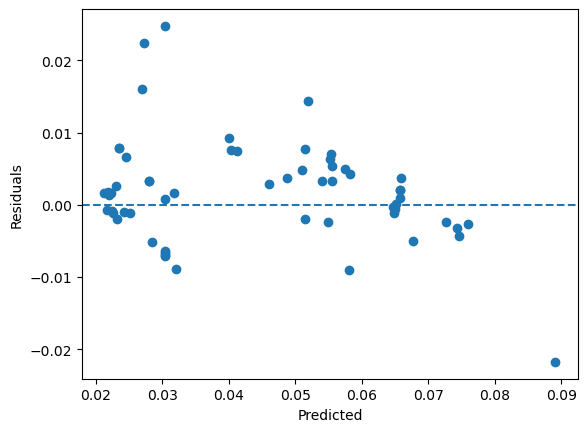

In [67]:
plot_residual(xgb, X_test_imp, y_test)

In [68]:
all_results = pd.concat([ridge_results, rf_results, xgb_results], ignore_index = True)

In [69]:
all_results

,Model,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Train_Explained_Var,Test_Explained_Var
0,Ridge,0.000059,0.000076,0.007688,0.008699,0.005377,0.006889,0.858641,0.770314,0.858641,0.782378
1,RF,0.000016,0.000034,0.003971,0.005830,0.002319,0.004548,0.962295,0.896838,0.962297,0.903058
2,XGB,0.000006,0.000055,0.002416,0.007403,0.001429,0.005222,0.986040,0.833633,0.986040,0.842779
